# DRAGON REAL ESTATE - PRICE PREDICTOR

In [1]:
import pandas as pd
import numpy as np

In [2]:
housing= pd.read_csv("data.csv")

In [3]:
housing.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [6]:
housing["CHAS"]

0      0
1      0
2      0
3      0
4      0
      ..
501    0
502    0
503    0
504    0
505    0
Name: CHAS, Length: 506, dtype: int64

In [7]:
housing["CHAS"].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

In [8]:
pd.set_option("display.max_rows",510)

In [9]:
housing["CHAS"].value_counts()

CHAS
0    471
1     35
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt


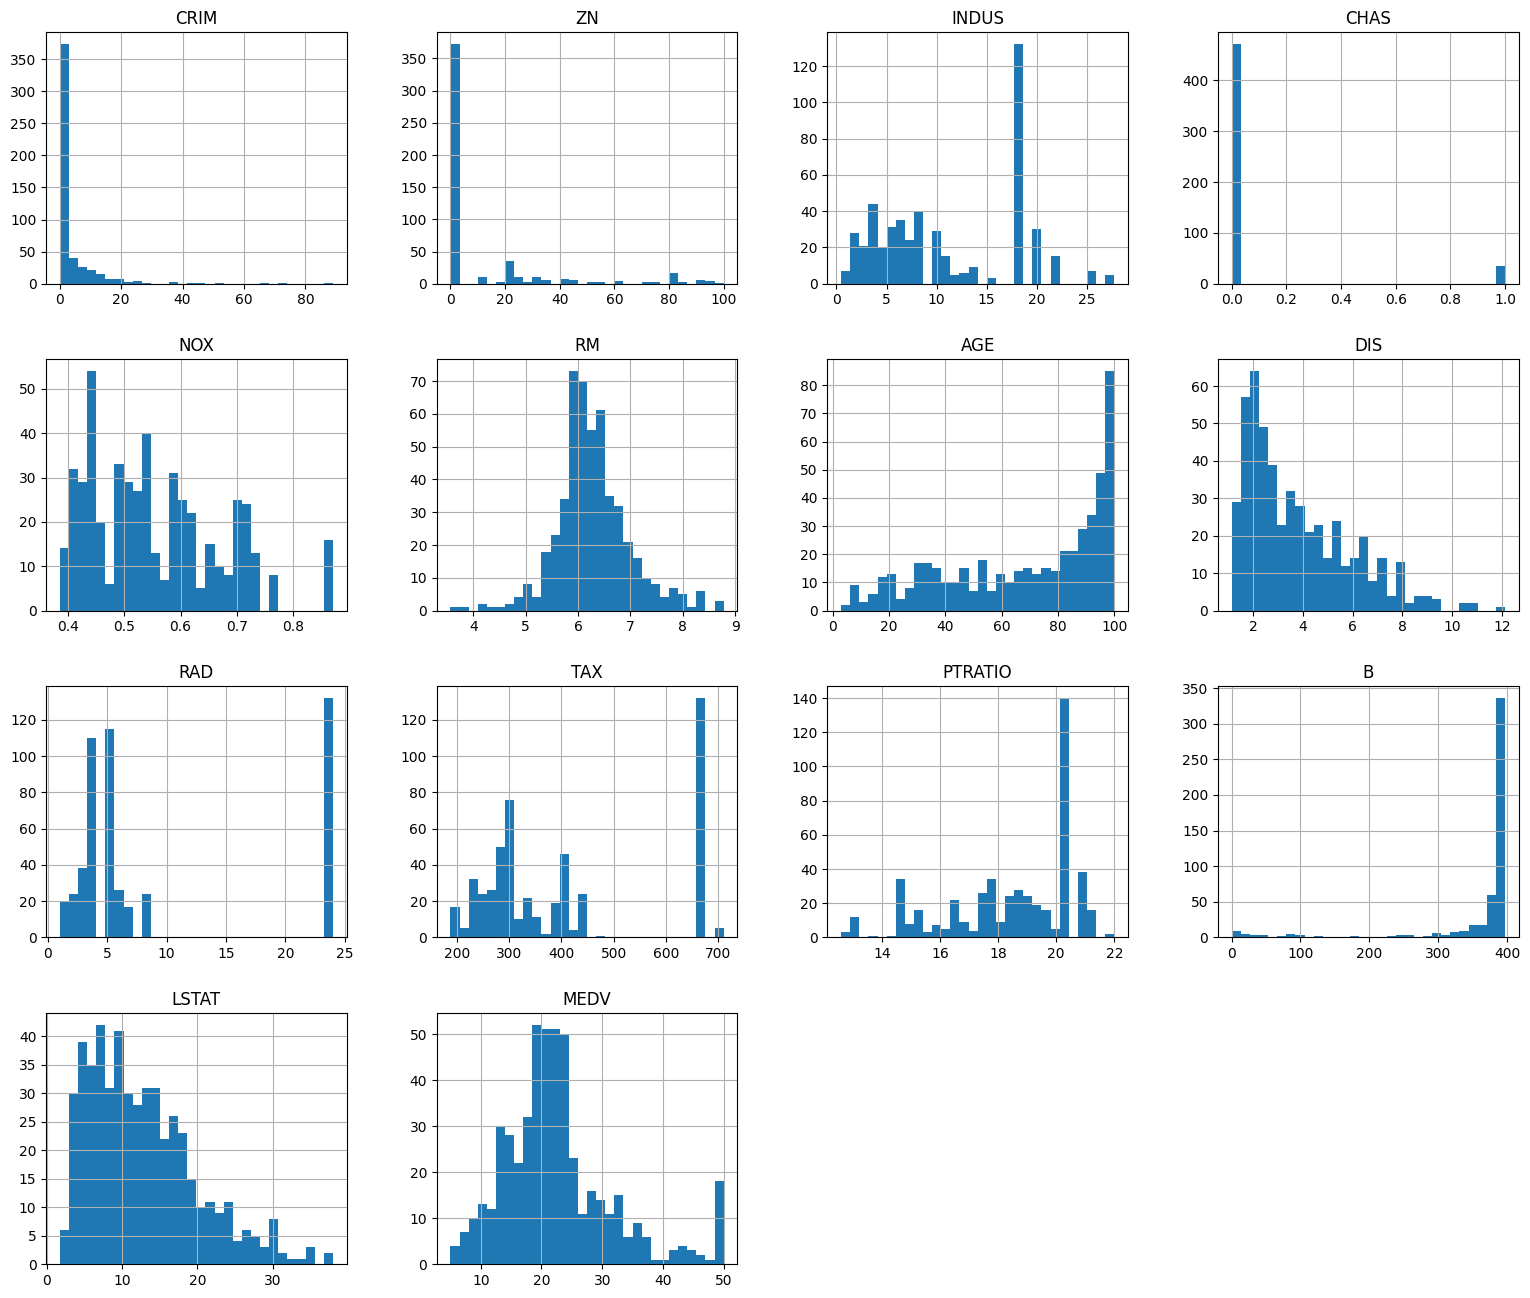

In [11]:
housing.hist(bins=30,figsize=(19,16))
plt.show()

In [12]:
housing.shape

(506, 14)

# train test splitting

In [13]:
"""
import numpy as np 

def split_train_test(data, test_ratio):
    np.random.seed(42)          #only one tym run
    shuffle=np.random.permutation(len(data))
    test_set_size= int(len(data)* test_ratio)
    test_indices= shuffle[:test_set_size]
    train_indices=shuffle[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
    """

'\nimport numpy as np \n\ndef split_train_test(data, test_ratio):\n    np.random.seed(42)          #only one tym run\n    shuffle=np.random.permutation(len(data))\n    test_set_size= int(len(data)* test_ratio)\n    test_indices= shuffle[:test_set_size]\n    train_indices=shuffle[test_set_size:]\n    return data.iloc[train_indices], data.iloc[test_indices]\n    '

In [14]:
# train_set,test_set=split_train_test(housing, 0.2)

In [15]:
# print (f"rows in train set: {len(train_set)},\n rows in test set:{len(test_set)}")

In [16]:
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(housing, test_size=0.2,random_state=42)

print (f"rows in train set :{len(train_set)} ,\n rows in test set :{len(test_set)}")

rows in train set :404 ,
 rows in test set :102


In [17]:
#for equal data at both train and test.........
from sklearn.model_selection import StratifiedShuffleSplit

In [18]:
split=StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index, test_index in split.split(housing,housing["CHAS"]):
    strat_train_set=housing.loc[train_index]
    strat_test_set=housing.loc[test_index]

In [19]:
 strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404 entries, 254 to 216
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     404 non-null    float64
 1   ZN       404 non-null    float64
 2   INDUS    404 non-null    float64
 3   CHAS     404 non-null    int64  
 4   NOX      404 non-null    float64
 5   RM       404 non-null    float64
 6   AGE      404 non-null    float64
 7   DIS      404 non-null    float64
 8   RAD      404 non-null    int64  
 9   TAX      404 non-null    int64  
 10  PTRATIO  404 non-null    float64
 11  B        404 non-null    float64
 12  LSTAT    404 non-null    float64
 13  MEDV     404 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 47.3 KB


In [20]:
 strat_train_set["CHAS"].value_counts()

CHAS
0    376
1     28
Name: count, dtype: int64

In [21]:
strat_test_set["CHAS"].value_counts()

CHAS
0    95
1     7
Name: count, dtype: int64

In [22]:
# 95/7

In [23]:
# 376/28

# looking for co-relations.

In [24]:
corr_mat=housing.corr()

In [25]:
corr_mat["MEDV"].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

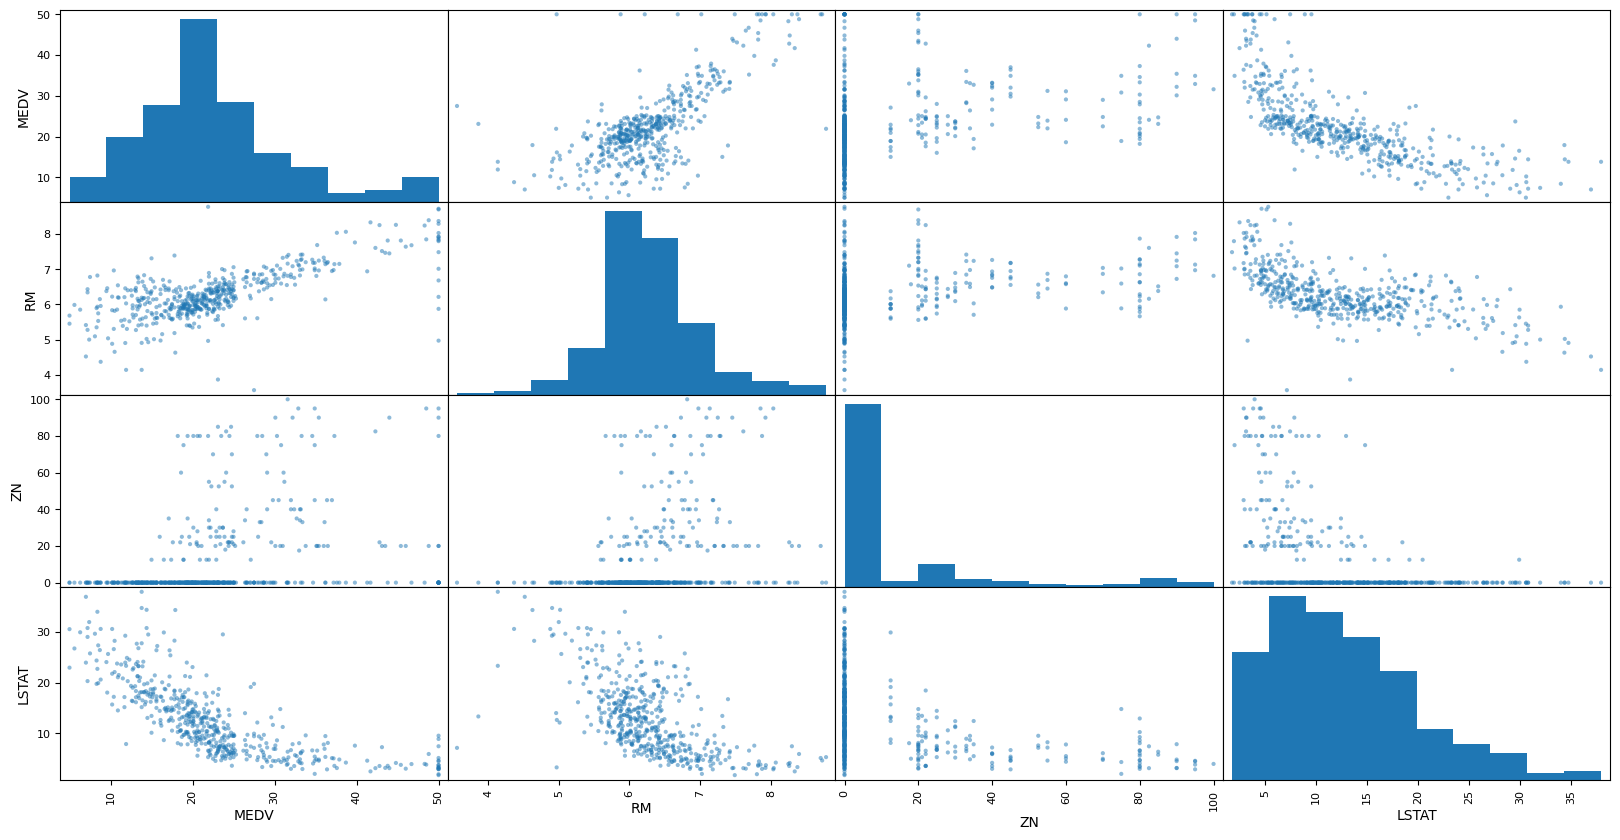

In [26]:
from pandas.plotting import scatter_matrix
attributes=["MEDV","RM","ZN","LSTAT"]
scatter_matrix(housing[attributes],figsize=(20,10))
plt.show()

# trying out attribute combinations

In [27]:
housing["TAXRM"]= housing["TAX"]/ housing["RM"]

In [28]:
housing["TAXRM"]

0       45.019011
1       37.688834
2       33.681280
3       31.723350
4       31.061984
5       34.525661
6       51.729874
7       50.388853
8       55.229977
9       51.798801
10      48.769014
11      51.755700
12      52.810324
13      51.605312
14      50.360892
15      52.622557
16      51.727043
17      51.252087
18      56.268328
19      53.605727
20      55.116697
21      51.466890
22      49.983719
23      52.812661
24      51.823093
25      54.831220
26      52.812661
27      50.768976
28      47.267129
29      45.999401
30      53.737091
31      50.559947
32      51.596639
33      53.850202
34      50.360892
35      47.025114
36      47.765794
37      47.692308
38      46.765002
39      38.210766
40      35.876993
41      34.416544
42      37.769493
43      37.514088
44      38.391827
45      41.006688
46      40.269616
47      38.640133
48      43.156140
49      41.592288
50      40.751300
51      39.738348
52      37.321456
53      40.513505
54      79.653533
55      31

In [29]:
housing["ROOM_PER_HOUSE"] = housing["RM"] / housing["DIS"]

In [30]:
housing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,TAXRM,ROOM_PER_HOUSE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,45.019011,1.607579
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,37.688834,1.292706
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,33.681280,1.446518
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,31.723350,1.154366
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,31.061984,1.178945


In [31]:
corr_matrix=housing.corr()
corr_matrix["MEDV"].sort_values(ascending=False)

MEDV              1.000000
RM                0.695360
ZN                0.360445
B                 0.333461
DIS               0.249929
CHAS              0.175260
ROOM_PER_HOUSE   -0.154830
AGE              -0.376955
RAD              -0.381626
CRIM             -0.388305
NOX              -0.427321
TAX              -0.468536
INDUS            -0.483725
PTRATIO          -0.507787
TAXRM            -0.537650
LSTAT            -0.737663
Name: MEDV, dtype: float64

In [32]:
housing = strat_train_set.drop("MEDV",axis=1)
housing_labels= strat_train_set["MEDV"].copy()                                                                                                # separate feature and label

In [33]:
from sklearn.impute import SimpleImputer                      #for missing val........if present
imputer=SimpleImputer(strategy="median")
imputer.fit(housing)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [34]:
imputer.statistics_

array([2.86735e-01, 0.00000e+00, 9.90000e+00, 0.00000e+00, 5.38000e-01,
       6.21000e+00, 7.82000e+01, 3.12220e+00, 5.00000e+00, 3.37000e+02,
       1.90000e+01, 3.90955e+02, 1.15700e+01])

In [35]:
x=imputer.transform(housing)

In [36]:
housing_tr=pd.DataFrame(x,columns=housing.columns)

# pipeline creating

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
my_pipeline= Pipeline([
    ("imputer ", SimpleImputer(strategy="median")) ,
    ("std_scale", StandardScaler())
     ])

In [38]:
housing_num_tr=my_pipeline.fit_transform(housing)

In [39]:
housing_num_tr.shape

(404, 13)

In [40]:
housing_num_tr

array([[-0.43942006,  3.12628155, -1.12165014, ..., -0.97491834,
         0.41164221, -0.86091034],
       [-0.44352175,  3.12628155, -1.35893781, ..., -0.69277865,
         0.39131918, -0.94116739],
       [ 0.15682292, -0.4898311 ,  0.98336806, ...,  0.81196637,
         0.44624347,  0.81480158],
       ...,
       [-0.43525657, -0.4898311 , -1.23083158, ..., -0.22254583,
         0.41831233, -1.27603303],
       [ 0.14210728, -0.4898311 ,  0.98336806, ...,  0.81196637,
        -3.15239177,  0.73869575],
       [-0.43974024, -0.4898311 ,  0.37049623, ..., -0.97491834,
         0.41070422,  0.09940681]], shape=(404, 13))

# selecting model

In [41]:
from sklearn.linear_model import LinearRegression          #not good
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
#model=DecisionTreeRegressor()
#model=LinearRegression()
model=RandomForestRegressor()
model.fit(housing_num_tr, housing_labels)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
some_data= housing.iloc[:5]
some_labels=housing_labels.iloc[:5]
prep_data= my_pipeline.transform(some_data)
model.predict(prep_data)

array([22.499, 25.597, 16.542, 23.382, 23.499])

In [43]:
list(some_labels)

[21.9, 24.5, 16.7, 23.1, 23.0]

# evauating the model

In [44]:
from sklearn.metrics import mean_squared_error
housing_predictions=model.predict(housing_num_tr)
mse=mean_squared_error(housing_labels,housing_predictions)
rmse=np.sqrt(mse)                   #will remove the square


In [45]:
rmse

np.float64(1.193151996035527)

# using better evaluation technique - cross validation  becz it is now overfitted  

In [46]:
from sklearn.model_selection import cross_val_score
scores= cross_val_score(model,housing_num_tr, housing_labels, scoring="neg_mean_squared_error",cv=10)           #sklearn needs higher so better score will appears
rmse_score= np.sqrt(-scores)                                                                                     #mse needs smaller for good accuracy

In [47]:
rmse_score


array([2.78711764, 2.92411234, 4.44787344, 2.5750465 , 3.51289621,
       2.5993484 , 4.91561751, 3.39434606, 3.30088075, 3.33363073])

In [48]:
def print_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std()) 


In [49]:
print_scores(rmse_score)

Scores: [2.78711764 2.92411234 4.44787344 2.5750465  3.51289621 2.5993484
 4.91561751 3.39434606 3.30088075 3.33363073]
Mean: 3.379086957605857
Standard deviation: 0.7308525002244495


# Saving the model

In [50]:
from joblib import dump,load
dump(model,"Dragon.joblib")

['Dragon.joblib']

# Testing model on test data

In [51]:
X_test= strat_test_set.drop(columns="MEDV",axis=1)
Y_test=strat_test_set["MEDV"].copy()
X_test_prepared= my_pipeline.transform(X_test) 
final_pred=model.predict(X_test_prepared)
final_mse=mean_squared_error(Y_test,final_pred)
final_rmse=np.sqrt(final_mse)

In [52]:
final_rmse

np.float64(2.9159150532961724)

In [53]:
print(final_pred,    list(Y_test))

[24.338 11.346 25.154 21.838 18.663 14.812 20.155 14.552 31.652 41.317
 19.748 11.871 25.822 28.392 19.824 10.843 31.212 14.348 23.649 18.549
 20.177 17.59  18.076 22.084 19.221 32.122 16.193 33.245  8.476 33.817
 23.714 21.322 22.868 10.842 20.939 11.581 42.826 24.504 23.565 41.199
 24.051 30.116 20.698 20.546 18.553 33.061 43.541 20.049 20.662 22.02
 20.99  14.83  21.537 14.839 25.084 33.037 42.648 29.675 18.983 21.077
 46.733  9.826 18.585 25.636 14.89  33.37  19.542 18.35  19.284 34.696
 25.106 22.711 21.183 22.41  34.582 12.269 15.686 19.948 20.761 21.726
 22.553 21.286 13.734 22.895 20.425 21.175 13.963 21.439 22.098 23.339
 18.566 27.665  7.526 26.525 18.798 29.346 19.876 31.296 14.717 26.13
 21.731 20.325] [16.5, 10.2, 30.1, 23.0, 14.4, 15.6, 19.4, 14.1, 30.3, 35.2, 23.1, 13.8, 25.0, 27.9, 19.5, 12.3, 32.2, 13.5, 23.8, 21.7, 19.2, 19.5, 10.4, 23.2, 18.6, 28.5, 15.2, 32.0, 7.2, 34.6, 20.1, 20.6, 23.6, 13.1, 23.8, 12.7, 43.1, 24.7, 22.2, 44.0, 28.1, 31.0, 21.7, 23.4, 19.5, 33.1, 